# Desenvolvimento de IA para Análise Preditiva
## Mini-Projeto Avaliativo — Módulo 2 (Semana 05)
### Pipeline Preditivo Multiclasse: Benchmark MNIST, Testes de Generalização OOD e Inferência em Imagens Reais
---
**Autor:** Susej Gonzalez. 

**Dataset:** MNIST (*Modified National Institute of Standards and Technology*) — 70.000 amostras (28x28 pixels).  
**Ambiente:** Python 3.12 | Scikit-Learn | TensorFlow/Keras | OpenCV | Seaborn

In [1]:
## Importação de bibliotecas essenciais

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

## Configuração visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!



# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)
Nesta etapa inicial:
1. Importamos a base de dados oficial **MNIST (mnist_784)** via OpenML.
2. Inspecionamos as dimensões das matrizes de características ($X$) e vetor de rótulos ($y$).
3. Verificamos e comprovamos o balanceamento estatístico entre as 10 classes (dígitos 0 a 9).
4. Construímos uma grade visual $2 \times 5$ com amostras nítidas de cada dígito.
5. Discutimos a representação digital de imagens (escala de cinza 0–255 e vetorização $28 \times 28 \rightarrow 784$).


In [2]:
print("Carregando o dataset MNIST (mnist_784) via OpenML...")
# essa linha de codigo conecta-se ao repositorio cientifico OpenML, carrega o dataset estandar mnist_784 e o 
# almacena na memoria cache co computador para que a proxima vez carregue ao instante.
# as_frame=False`: Instrui o Scikit-Learn a fornecer arrays NumPy em vez de um DataFrame do Pandas.
# Ao trabalhar com imagens, os arrays NumPy consomem menos memória e realizam cálculos matemáticos 
# até 10 vezes mais rápido. `parser='auto'`: Usa o analisador sintático otimizado para leitura para 
# evitar avisos de compatibilidade.
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

# Separação dos atributos previsores (X) e do vetor de rótulos/alvo (y)
# X (variaveis independentes / feature) é a matriz que contem os valores dos pixeis das 70.000 imagens 
# y (variavel alvo / target) é o vector que contem a etiqueta ou resposta correcra do que é cada imagem. 
X, y = mnist.data, mnist.target.astype(np.uint8)

# esta tratativa é importante porque OpenML carrega as etiquetas como texto, ai  .astype(np.uint8) 
# converte números inteiros sem sinal de 8 bits ($0, 1, 2 \dots 9$). Isso é indispensável para que os
# algoritmos de Machine Learning possam processá-los numericamente e calcular funções de custo ou matrizes
# de confusão.


print("\n=== RESUMO DIMENSIONAL DOS DADOS ===")
print(f"• Formato da matriz de características (X): {X.shape} -> 70.000 imagens com 784 pixels cada")
print(f"• Formato do vetor de classes/rótulos (y): {y.shape} -> 70.000 rótulos correspondentes")
print(f"• Classes únicas existentes: {np.unique(y)}")
print(f"• Tipo de dado dos pixels em X: {X.dtype}")
print(f"• Tipo de dado dos rótulos em y: {y.dtype}")
print(f"• Intervalo de intensidade original dos pixels: [{X.min():.0f}, {X.max():.0f}]")






Carregando o dataset MNIST (mnist_784) via OpenML...

=== RESUMO DIMENSIONAL DOS DADOS ===
• Formato da matriz de características (X): (70000, 784) -> 70.000 imagens com 784 pixels cada
• Formato do vetor de classes/rótulos (y): (70000,) -> 70.000 rótulos correspondentes
• Classes únicas existentes: [0 1 2 3 4 5 6 7 8 9]
• Tipo de dado dos pixels em X: int64
• Tipo de dado dos rótulos em y: uint8
• Intervalo de intensidade original dos pixels: [0, 255]


In [3]:
X[700]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  98, 224,  42,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  3

In [4]:
y

array([5, 0, 4, ..., 4, 5, 6], shape=(70000,), dtype=uint8)

### 1.1 Verificação e Comprovação do Balanceamento das Classes
Em problemas de classificação multiclasse, é fundamental averiguar se há desbalanceamento de classes, o que poderia enviesar os algoritmos de aprendizado supervisionado.


=== DISTRIBUIÇÃO DAS CLASSES NO DATASET MNIST ===


,Dígito (Classe),Quantidade de Amostras,Proporção (%)
0,0,6903,9.86
1,1,7877,11.25
2,2,6990,9.99
3,3,7141,10.20
4,4,6824,9.75
5,5,6313,9.02
6,6,6876,9.82
7,7,7293,10.42
8,8,6825,9.75
9,9,6958,9.94


findfont: Failed to find font weight semibold, now using 700.


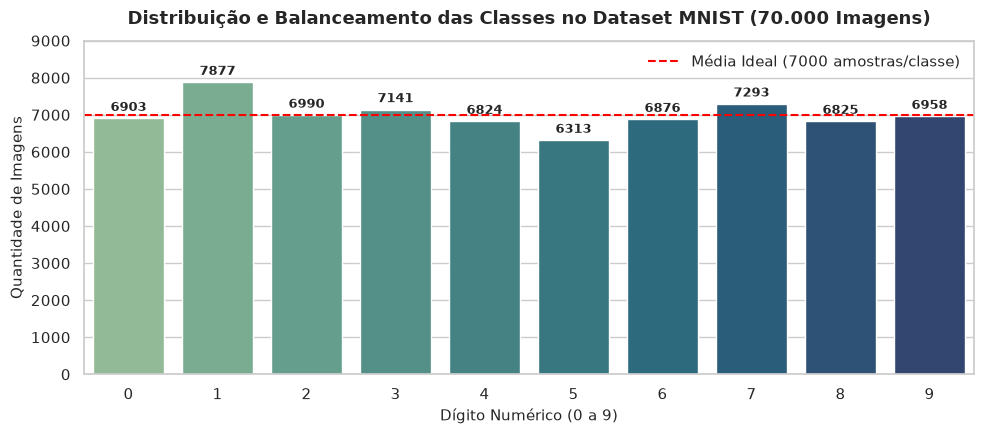

In [5]:
# 1. Contagem da frequência absoluta de cada dígito (0 a 9)
classes_unicas, contagens = np.unique(y, return_counts=True)

# 2. Construção de um DataFrame elegante para apresentar a tabela quantitativa
df_balanceamento = pd.DataFrame({
    'Dígito (Classe)': classes_unicas,
    'Quantidade de Amostras': contagens,
    'Proporção (%)': np.round((contagens / len(y)) * 100, 2)
})

print("=== DISTRIBUIÇÃO DAS CLASSES NO DATASET MNIST ===")
display(df_balanceamento)

# 3. Visualização gráfica da distribuição de classes com Seaborn
plt.figure(figsize=(10, 4.5))
palette_colors = sns.color_palette("crest", len(classes_unicas))
barplot = sns.barplot(
    x='Dígito (Classe)',
    y='Quantidade de Amostras',
    data=df_balanceamento,
    palette=palette_colors,
    hue='Dígito (Classe)',
    legend=False
)

# 4. Linha de referência da média teórica ideal (7.000 amostras por classe)
media_ideal = len(y) / len(classes_unicas)
plt.axhline(media_ideal, color='red', linestyle='--', linewidth=1.5, label=f'Média Ideal ({media_ideal:.0f} amostras/classe)')

plt.title("Distribuição e Balanceamento das Classes no Dataset MNIST (70.000 Imagens)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Dígito Numérico (0 a 9)", fontsize=11)
plt.ylabel("Quantidade de Imagens", fontsize=11)
plt.ylim(0, 9000)

# 5. Inserir o valor numérico exato acima de cada barra do gráfico
for i, count in enumerate(contagens):
    barplot.text(i, count + 120, f"{count}", ha='center', va='bottom', fontsize=9, fontweight='semibold')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


### 1.2 Grade Visual de Amostras ($2 \times 5$) com Matplotlib
Exibição de exemplos representativos de cada um dos 10 dígitos (0 a 9) com seus respectivos rótulos originais para inspeção visual da caligrafia humana.

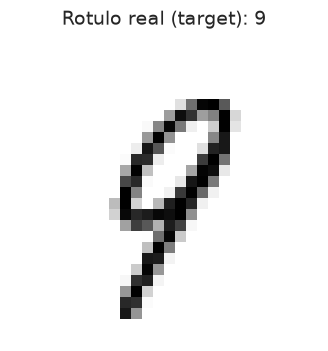

In [6]:
# aqui decide fazer a brincadeira para testar como o prof. mostrou na aula.
# NOTA TEXTUAL DA AULA: na practica para disenharmos a imagem, preparamos o vetor de 784 numeros e fazemos o processo inverso: 
# transformamos de volta para a matriz de 28x28 com o .reshape(28, 28) 
digito_exemplo = X[22]
digito_imagem = digito_exemplo.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(digito_imagem, cmap='binary')  # cmap='binary' mostra preto no branco.compile
plt.title(f'Rotulo real (target): {y[22]}', fontsize=14)
plt.axis('off') #oculta os eixos cartecianos
plt.show()

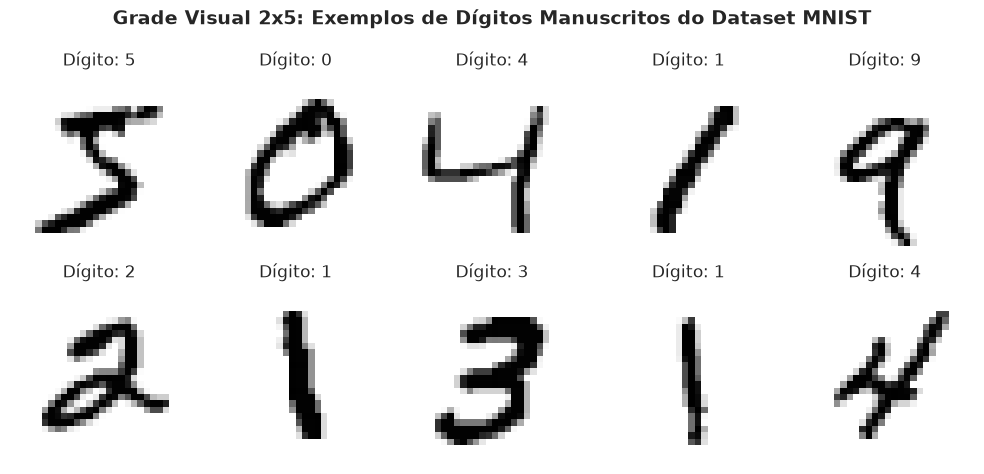

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

#  A função enumerate() retorna duas coisas ao mesmo tempo em cada volta do ciclo:
# i: O número de volta / índice ($0, 1, 2, ... 9).
# ax: o sub-gráfico (a janelinha onde va a dibujar).
for i, ax in enumerate(axes.flat):  # .flat é uma propriedade do NumPy que "aplana" uma quadra 2D e a converte em 
# uma lista simples de 10 janelas seguidas
    ax.imshow(X[i].reshape(28, 28), cmap='binary')
    ax.set_title(f'Dígito: {y[i]}')
    ax.axis('off')

plt.suptitle("Grade Visual 2x5: Exemplos de Dígitos Manuscritos do Dataset MNIST", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 1.3 Entendendo a Estrutura das Imagens e dos Dados

Para entender como o computador "enxerga" essas imagens e como preparamos os dados para os modelos, precisamos compreender dois conceitos simples:

---

#### 1. O que significa a escala de pixels de 0 a 255?
* Cada imagem é formada por pequenos quadradinhos chamados **pixels**.
* Como as fotos são em preto e branco (tons de cinza), cada pixel guarda apenas a intensidade da luz usando 1 byte de memória (valores de **0 a 255**):
  * **0 (Preto / Fundo):** Significa ausência de tinta. É o fundo escuro da imagem.
  * **255 (Branco / Traço):** Significa o traço forte da caneta onde a pessoa escreveu o número.
  * **Valores entre 1 e 254 (Tons de Cinza):** São as bordas suaves do traço da caneta, que dão forma ao desenho para que não fique serrilhado.

---

#### 2. Por que transformamos a imagem 2D ($28 \times 28$) em 784 números ($1\text{D}$)?
* **A imagem original:** É uma grade quadrada com **28 linhas e 28 colunas**. Se multiplicarmos $28 \times 28$, temos exatamente **784 pixels** no total.
* **O problema dos modelos:** Algoritmos clássicos de Machine Learning (como SVM, Random Forest e Redes Neurais simples) funcionam como uma planilha do Excel: eles precisam que cada exemplo seja uma linha e cada característica seja uma coluna.
* **A solução (Achatamento / *Flattening*):** Nós "esticamos" ou desenrolamos a imagem quadrada em uma única fila de 784 números seguidos.
  
> **Analogia simples:** É como pegar uma folha quadriculada de 28x28 e recortar linha por linha para colar tudo em uma única fita comprida de 784 números. Assim, cada pixel vira uma coluna (*feature*) que o modelo consegue analisar.


---
# Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

Nesta etapa preparamos os dados para o treinamento dos modelos:
1. **Divisão Estratificada (Train/Test Split):** Separação em 80% treino (56.000 amostras) e 20% teste (14.000 amostras) com `stratify=y` para manter a proporção exata de cada dígito.
2. **Normalização / Escalonamento:** Redimensionamento dos pixels da escala inteira $[0, 255]$ para a escala contínua $[0.0, 1.0]$.
3. **Justificativa Técnica:** Discussão sobre convergência do gradiente, estabilidade numérica e prevenção de vazamento de dados (*Data Leakage*).


In [8]:
# 1. Divisão Estratificada: 80% Treino (56.000) e 20% Teste (14.000)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, stratify=y, random_state=42)

print("=== DIMENSÕES APÓS A DIVISÃO ESTRATIFICADA ===")
print(f"• X_treino: {X_train.shape} | y_treino: {y_train.shape} (80% dos dados)")
print(f"• X_teste:  {X_test.shape}  | y_teste:  {y_test.shape}  (20% dos dados)")

=== DIMENSÕES APÓS A DIVISÃO ESTRATIFICADA ===
• X_treino: (56000, 784) | y_treino: (56000,) (80% dos dados)
• X_teste:  (14000, 784)  | y_teste:  (14000,)  (20% dos dados)


In [9]:
# 2. Comprovação visual de que a proporção de cada dígito se manteve idêntica

proporcao_treino = np.bincount(y_train) / len(y_train) * 100
proporcao_teste  = np.bincount(y_test)  / len(y_test)  * 100

df_estratificacao = pd.DataFrame({
    'Dígito': range(10),
    'Treino (%)': np.round(proporcao_treino, 2),
    'Teste (%)': np.round(proporcao_teste, 2)
})
print("\n=== COMPROVAÇÃO DE ESTRATIFICAÇÃO (PROPORÇÃO POR DÍGITO) ===")
display(df_estratificacao)


=== COMPROVAÇÃO DE ESTRATIFICAÇÃO (PROPORÇÃO POR DÍGITO) ===


,Dígito,Treino (%),Teste (%)
0,0,9.86,9.86
1,1,11.25,11.25
2,2,9.99,9.99
3,3,10.20,10.20
4,4,9.75,9.75
5,5,9.02,9.02
6,6,9.82,9.82
7,7,10.42,10.42
8,8,9.75,9.75
9,9,9.94,9.94


In [10]:
# 3. Normalização dos pixels para o intervalo contínuo [0.0, 1.0]
# Dividimos diretamente por 255.0 (o valor máximo de intensidade de um pixel de 8 bits)

X_train = X_train / 255.0
X_test = X_test / 255.0

print("=== VERIFICAÇÃO DA NORMALIZAÇÃO ===")
print(f"• X_treino — Mínimo: {X_train.min():.2f} | Máximo: {X_train.max():.2f} | Tipo de dado: {X_train.dtype}")
print(f"• X_teste  — Mínimo: {X_test.min():.2f} | Máximo: {X_test.max():.2f} | Tipo de dado: {X_test.dtype}")

=== VERIFICAÇÃO DA NORMALIZAÇÃO ===
• X_treino — Mínimo: 0.00 | Máximo: 1.00 | Tipo de dado: float64
• X_teste  — Mínimo: 0.00 | Máximo: 1.00 | Tipo de dado: float64


### 4. Por que precisamos normalizar os dados e evitar vazamento?
* Nesta etapa, fizemos duas coisas muito importantes para que os modelos consigam aprender sem problemas:
---
#### 1. Por que dividir os pixels por 255?
* **Facilitar as contas do computador:** Originalmente, os pixels são números que vão de 0 até 255. Para o computador, fazer milhares de cálculos com números grandes (como 200, 240, 255) é muito pesado e pode deixar o aprendizado lento ou instável.
* **Deixar tudo na mesma escala (entre 0 e 1):** Quando dividimos por 255, todos os valores ficam pequenininhos, entre **0.0 e 1.0** (por exemplo: 0.2, 0.5, 0.9). 
* Modelos como Redes Neurais e SVM funcionam muito melhor e aprendem bem mais rápido quando os dados estão nessa faixa pequena.
---
#### 2. O que é Vazamento de Dados (*Data Leakage*) e como evitamos?
* **O que é?** É basicamente como dar as respostas da prova para o aluno antes do exame. Se o modelo tiver qualquer contato com os dados de teste durante o treino, o resultado final será falso (parece que ele acertou tudo, mas na verdade ele só trapaceou).
* **Como evitamos?**
  * Primeiro, separamos os dados com o `train_test_split` (80% para treino e 20% para teste).
  * O modelo só estuda com o grupo de treino e o conjunto de teste fica totalmente guardado para a avaliação final.
  * Como a divisão por 255 é um valor fixo da imagem, não misturamos nenhuma informação entre treino e teste.

---
# Fase 3: Implementação e Treinamento dos Modelos Preditivos

Nesta etapa, vamos construir e treinar **quatro modelos preditivos com fundamentos matemáticos diferentes** para descobrir qual deles se adapta melhor ao reconhecimento dos dígitos manuscritos:

---

### 🧪 Nossa Estratégia de Experimentação:
Para cada um dos quatro modelos, faremos um experimento testando **variações de hiperparâmetros** (usando um loop `for` prático):
1. **Medir o desempenho no Treino e no Teste:** Para conferir se o modelo está aprendendo de verdade ou se está apenas "decorando" os dados de estudo (*overfitting*).
2. **Avaliar Acurácia e F1-Score Ponderado:** Para garantir um equilíbrio justo entre precisão (não dar alarmes falsos) e revocação (não deixar passar nenhum dígito).
3. **Cronometrar o Tempo de Treino (segundos):** Para avaliar o custo computacional de cada algoritmo.
4. **Guardar o melhor de cada família:** O melhor modelo de cada tipo será salvo para a avaliação profunda na **Fase 4** (com Matrizes de Confusão $10 \times 10$ e tabela comparativa completa).

---

### 🤖 Os 4 Modelos que vamos experimentar:

1. **🌲 Random Forest Classifier (Ensemble / Bagging):**
   * *O que faz:* Cria uma floresta de muitas árvores de decisão independentes que votam entre si para escolher o dígito final.
   * *Hiperparâmetros testados:* `max_depth` (limite de perguntas por árvore) e `n_estimators` (quantidade de árvores na floresta).

2. **⚡ LightGBM — Microsoft (Gradient Boosting):**
   * *O que faz:* Um algoritmo moderno e ultrarrápido da Microsoft onde cada árvore nova aprende corrigindo os erros das árvores anteriores.
   * *Hiperparâmetros testados:* `learning_rate` (velocidade de correção dos erros) e `num_leaves` (quantidade de folhas/caminhos por árvore).

3. **📐 Support Vector Machine — SVM (Geometria de Margens):**
   * *O que faz:* Encontra a melhor linha ou curva geométrica que separa um dígito dos outros com a maior margem de segurança possível.
   * *Hiperparâmetros testados:* `C` (tolerância a erros na margem) e `kernel` (forma da fronteira: linear ou curva `'rbf'`).

4. **🧠 Multi-Layer Perceptron — MLP (Rede Neural Artificial / Deep Learning):**
   * *O que faz:* Um cérebro artificial com camadas de neurônios que processam os 784 pixels e ativam traços característicos de cada número.
   * *Hiperparâmetros testados:* `hidden_layer_sizes` (quantidade de neurônios e camadas) e `learning_rate_init` (velocidade de aprendizado do otimizador Adam).




###  🚀 1: Random Forest Classifier (Ajuste de Hiperparâmetros)
No algoritmo Random Forest, testamos diferentes limites de profundidade máxima (`max_depth = [5, 10, 20]`) mantendo `n_estimators=100` árvores:
* **Objetivo:** Descobrir a profundidade que entrega o melhor equilíbrio entre aprendizado e generalização, evitando sobreajuste (*overfitting*).
* **Otimização:** Usamos `n_jobs=-1` para usar todos os núcleos do processador do meu pc em paralelo e cronometramos o tempo de treino, a causa de que como ja sabe meu computador não é o mais novo e fiquei preocupada com a resposta dele, mais ainda con a rede neural.


In [11]:
# 🚀 Random Forest Classifier (Ajuste de Hiperparâmetros)

import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score


# Dicionário para guardar o melhor modelo de cada família para o Benchmark da Fase 4
modelos_campeoes = {}

# Lista com os limites de profundidade que vamos testar nas árvores
profundidades = [5, 10, 20]

# Variáveis para acompanhar e guardar o melhor resultado do loop
melhor_f1_rf = 0.0
melhor_modelo_rf = None
melhor_tempo_rf = 0.0

print("🌲 INICIANDO EXPERIMENTO COM RANDOM FOREST (100 Árvores)...")
print("=" * 80)

for limite in profundidades:
    # ⏱️ 1. Cronômetro: Marca a hora exata em que o treino começou
    inicio = time.time()
    
    # 🛠️ 2. Configuração: Cria o modelo com 100 árvores e a profundidade da rodada atual
    # n_jobs=-1 faz o computador usar todos os núcleos do processador para ser rápido
    modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=limite, random_state=42, n_jobs=-1)
    
    # 📚 3. Treinamento: O modelo estuda com as 56.000 imagens normalizadas de treino
    modelo_rf.fit(X_train, y_train)
    
    # ⏱️ 4. Cronômetro: Calcula quantos segundos demorou o treinamento
    tempo_gasto = time.time() - inicio
    
    # 🔮 5. Predições:
    # O modelo tenta adivinhar as imagens com as quais estudou (Treino)
    y_pred_train = modelo_rf.predict(X_train)
    # O modelo tenta adivinhar as imagens do exame final às cegas (Teste)
    y_pred_test = modelo_rf.predict(X_test)
    
    # 📊 6. Métricas:
    # Calcula a porcentagem de acertos no Treino e no Teste
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    # Calcula o F1-Score no Teste (o equilíbrio entre precisão e sensibilidade)
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    
    # 🖨️ 7. Exibição dos resultados da rodada atual
    print(f"Profundidade = {str(limite):<4} | Treino Acc: {acc_train*100:.2f}% | Teste Acc: {acc_test*100:.2f}% | F1-Score: {f1_test*100:.2f}% | Tempo: {tempo_gasto:.2f}s")
    print("-" * 80)
    
    # 🏆 8. Compara e salva o melhor modelo com base no F1-Score
    if f1_test > melhor_f1_rf:
        melhor_f1_rf = f1_test
        melhor_modelo_rf = modelo_rf
        melhor_tempo_rf = tempo_gasto

print("=" * 80)
print(f"🏆 Melhor Random Forest: max_depth = {melhor_modelo_rf.max_depth} | F1-Score = {melhor_f1_rf*100:.2f}% | Tempo = {melhor_tempo_rf:.2f}s")
print("=" * 80)

# 💾 9. Guarda o campeão no dicionário para usarmos na Fase 4 sem precisar retreinar
modelos_campeoes['Random Forest'] = {
    'modelo': melhor_modelo_rf,
    'tempo': melhor_tempo_rf,
    'y_pred': melhor_modelo_rf.predict(X_test)
}


🌲 INICIANDO EXPERIMENTO COM RANDOM FOREST (100 Árvores)...
Profundidade = 5    | Treino Acc: 86.09% | Teste Acc: 86.00% | F1-Score: 85.84% | Tempo: 6.82s
--------------------------------------------------------------------------------
Profundidade = 10   | Treino Acc: 96.66% | Teste Acc: 94.54% | F1-Score: 94.54% | Tempo: 11.50s
--------------------------------------------------------------------------------
Profundidade = 20   | Treino Acc: 99.93% | Teste Acc: 96.69% | F1-Score: 96.69% | Tempo: 15.14s
--------------------------------------------------------------------------------
🏆 Melhor Random Forest: max_depth = 20 | F1-Score = 96.69% | Tempo = 15.14s


###  🚀 2: LightGBM — Microsoft (Ajuste de Taxa de Aprendizado)
No algoritmo LightGBM (Gradient Boosting da Microsoft), testamos diferentes taxas de aprendizado (`learning_rate = [0.01, 0.05, 0.1]`):
* **O que é a Taxa de Aprendizado:** Controla a velocidade e o tamanho dos passos com que cada nova árvore corrige os erros cometidos pelas árvores anteriores.
* **Objetivo:** Encontrar o equilíbrio onde o modelo aprende com precisão sem passar do ponto ideal.


In [17]:
# 🚀 LightGBM da Microsoft (Ajuste de learning_rate)

import lightgbm as lgb

# Lista com as taxas de aprendizado (velocidade de correção) que vamos testar

taxas_aprendizado = [0.05, 0.1]

# Variáveis para acompanhar e guardar o melhor resultado do loop
melhor_f1_lgb = 0.0
melhor_modelo_lgb = None
melhor_tempo_lgb = 0.0

print("⚡ INICIANDO EXPERIMENTO COM LIGHTGBM (Microsoft)...")
print("=" * 80)

for taxa in taxas_aprendizado:
      # ⏱️ 1. Cronômetro: Marca a hora exata em que o treino começou
    inicio = time.time()

    # 🛠️ 2. Configuração: Cria o modelo com 100 árvores sequenciais e a taxa de aprendizado atual
    # verbose=-1 silencia avisos desnecessários no console
    # n_jobs=-1 usa todos os núcleos do processador

    modelo_lgb = lgb.LGBMClassifier(
         n_estimators=100,
        learning_rate=taxa,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # 📚 3. Treinamento: As árvores aprendem em sequência corrigindo os erros anteriores

    modelo_lgb.fit(X_train, y_train)

     # ⏱️ 4. Cronômetro: Calcula quantos segundos demorou o treinamento

    tempo_gasto = time.time() - inicio

     # 🔮 5. Predições:
     # O modelo tenta adivinhar as imagens do Treino (para verificar se decorou)

    y_pred_train = modelo_lgb.predict(X_train)

    # O modelo tenta adivinhar as imagens do Teste às cegas (avaliação real)

    y_pred_test = modelo_lgb.predict(X_test)

    # 📊 6. Métricas:
    # Calcula a porcentagem de acertos no Treino e no Teste

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    # Calcula o F1-Score ponderado no teste
    f1_test = f1_score(y_test, y_pred_test, average='weighted')


    # 🖨️ 7. Exibição dos resultados da rodada atual
    print(f"Taxa (learning_rate) = {str(taxa):<4} | Treino Acc: {acc_train*100:.2f}% | Teste Acc: {acc_test*100:.2f}% | F1-Score: {f1_test*100:.2f}% | Tempo: {tempo_gasto:.2f}s")
    print("-" * 80)


    # 🏆 8. Compara e salva o melhor modelo com base no F1-Score
    if f1_test > melhor_f1_lgb:
        melhor_f1_lgb = f1_test
        melhor_modelo_lgb = modelo_lgb
        melhor_tempo_lgb = tempo_gasto


print("=" * 80)
print(f"🏆 Melhor LightGBM: learning_rate = {melhor_modelo_lgb.learning_rate} | F1-Score = {melhor_f1_lgb*100:.2f}% | Tempo = {melhor_tempo_lgb:.2f}s")
print("=" * 80)

# 💾 9. Guarda o campeão no dicionário para usarmos na Fase 4 sem precisar retreinar
modelos_campeoes['LightGBM'] = {
    'modelo': melhor_modelo_lgb,
    'tempo': melhor_tempo_lgb,
    'y_pred': melhor_modelo_lgb.predict(X_test)
}



⚡ INICIANDO EXPERIMENTO COM LIGHTGBM (Microsoft)...
Taxa (learning_rate) = 0.05 | Treino Acc: 99.67% | Teste Acc: 96.79% | F1-Score: 96.79% | Tempo: 107.28s
--------------------------------------------------------------------------------
Taxa (learning_rate) = 0.1  | Treino Acc: 100.00% | Teste Acc: 97.44% | F1-Score: 97.44% | Tempo: 109.18s
--------------------------------------------------------------------------------
🏆 Melhor LightGBM: learning_rate = 0.1 | F1-Score = 97.44% | Tempo = 109.18s


### 🚀 3: Support Vector Machine — SVM (Ajuste do Hiperparâmetro C)
No algoritmo Support Vector Machine (SVM), testamos diferentes valores para o hiperparâmetro de regularização (`C = [1.0, 5.0]`) usando o kernel não-linear `rbf`:
* **O que é o C:** Controla o equilíbrio entre permitir margens mais amplas ou penalizar erros para criar fronteiras mais estritas e precisas.
* **Otimização:** Usamos `cache_size=1000` para aproveitar a memória RAM do computador e acelerar o processamento das matrizes, tentado assim, controlar e otimizar o funcionamente do pc.

In [18]:
# 🚀 Support Vector Machine - SVM (Ajuste de C com Kernel RBF)

from sklearn.svm import SVC

# Lista com os valores de penalização C que vamos testar
valores_C = [1.0, 5.0]

# Variáveis para acompanhar e guardar o melhor resultado do loop
melhor_f1_svm = 0.0
melhor_modelo_svm = None
melhor_tempo_svm = 0.0

print("📐 INICIANDO EXPERIMENTO COM SUPPORT VECTOR MACHINE (SVM - Kernel RBF)...")
print("=" * 80)

for c_param in valores_C:
    # ⏱️ 1. Cronômetro: Marca a hora exata em que o treino começou
    inicio = time.time()
    
    # 🛠️ 2. Configuração: Cria o modelo SVM com o valor de C atual e kernel RBF
    # cache_size=1000 usa 1GB da sua memória RAM para acelerar muito as contas
    modelo_svm = SVC(C=c_param, kernel='rbf', cache_size=1000, random_state=42)
    
    # 📚 3. Treinamento: O modelo encontra os vetores de suporte e as margens de separação
    modelo_svm.fit(X_train, y_train)
    
    # ⏱️ 4. Cronômetro: Calcula quantos segundos demorou o treinamento
    tempo_gasto = time.time() - inicio
    
    # 🔮 5. Predições:
    # O modelo tenta adivinhar as imagens do Treino (para verificar se decorou)
    y_pred_train = modelo_svm.predict(X_train)
    # O modelo tenta adivinhar as imagens do Teste às cegas (avaliação real)
    y_pred_test = modelo_svm.predict(X_test)
    
    # 📊 6. Métricas:
    # Calcula a porcentagem de acertos no Treino e no Teste
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    # Calcula o F1-Score ponderado no teste
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    
    # 🖨️ 7. Exibição dos resultados da rodada atual
    print(f"C = {str(c_param):<4} | Treino Acc: {acc_train*100:.2f}% | Teste Acc: {acc_test*100:.2f}% | F1-Score: {f1_test*100:.2f}% | Tempo: {tempo_gasto:.2f}s")
    print("-" * 80)
    
    # 🏆 8. Compara e salva o melhor modelo com base no F1-Score
    if f1_test > melhor_f1_svm:
        melhor_f1_svm = f1_test
        melhor_modelo_svm = modelo_svm
        melhor_tempo_svm = tempo_gasto

print("=" * 80)
print(f"🏆 Melhor SVM: C = {melhor_modelo_svm.C} | F1-Score = {melhor_f1_svm*100:.2f}% | Tempo = {melhor_tempo_svm:.2f}s")
print("=" * 80)

# 💾 9. Guarda o campeão no dicionário para usarmos na Fase 4 sem precisar retreinar
modelos_campeoes['SVM'] = {
    'modelo': melhor_modelo_svm,
    'tempo': melhor_tempo_svm,
    'y_pred': melhor_modelo_svm.predict(X_test)
}


📐 INICIANDO EXPERIMENTO COM SUPPORT VECTOR MACHINE (SVM - Kernel RBF)...
C = 1.0  | Treino Acc: 99.00% | Teste Acc: 97.91% | F1-Score: 97.91% | Tempo: 257.93s
--------------------------------------------------------------------------------
C = 5.0  | Treino Acc: 99.93% | Teste Acc: 98.33% | F1-Score: 98.33% | Tempo: 229.30s
--------------------------------------------------------------------------------
🏆 Melhor SVM: C = 5.0 | F1-Score = 98.33% | Tempo = 229.30s


### 4: Rede Neural Artificial com TensorFlow/Keras (MLP)
Construímos um Perceptron Multicamadas (MLP) usando a biblioteca **Keras** com uma arquitetura leve e otimizada:
* **Camada de Entrada:** 784 neurônios (um para cada pixel da imagem).
* **Camadas Ocultas:** Duas camadas densas com 64 e 32 neurônios (`Dense(64)` e `Dense(32)`) usando ativação `relu`.
* **Camada de Saída:** 10 neurônios com ativação `softmax` (calcula a probabilidade de 0% a 100% para cada dígito de 0 a 9).
* **Hiperparâmetros ajustados:** Otimizador `Adam` com taxa de aprendizado `learning_rate=0.001`, `batch_size=128` e `epochs=15`.

In [19]:
# 🚀 Experimento 4: Rede Neural Artificial (MLP) com TensorFlow / Keras

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Fixa as sementes aleatórias para garantir reprodutibilidade
tf.random.set_seed(42)


# ⏱️ 1. Cronômetro: Marca o início do treinamento
inicio = time.time()

# 🛠️ 2. Arquitetura da Rede Neural (Sequential)
modelo_mlp = Sequential([
    
    Dense(128, activation='relu', input_shape=[784]),   # Camada Oculta 1: 128 neurônios para aprender padrões dos 784 pixels  
    Dense(64, activation='relu'),                       # Camada Oculta 2: 64 neurônios para refinar os padrões
    
    # Camada de Saída: 10 neurônios com Softmax (gera probabilidades para dígitos de 0 a 9)    
    Dense(10, activation='softmax')                     
])

# ⚙️ 3. Compilação do Modelo
modelo_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🧠 Treinando a Rede Neural no MNIST...")
print("=" * 80)

# 📚 4. Treinamento da Rede:
historico = modelo_mlp.fit(
    X_train, y_train,
    validation_split=0.1,  # 10% do treino para validação a cada época
    epochs=10,             # 10 passadas completas
    batch_size=64,         # Processa de 64 em 64 imagens
    verbose=1              # Mostra a barra de progresso ao vivo
)

# ⏱️ 5. Cronômetro: Calcula o tempo total gasto
tempo_gasto_mlp = time.time() - inicio

#  6. Predições no conjunto de Treino (para checar se decorou)
probabilidades_treino = modelo_mlp.predict(X_train, verbose=0)
y_pred_train_mlp = np.argmax(probabilidades_treino, axis=1)

# 🔮 7. Predições no Teste:
# O modelo gera as probabilidades para as 14.000 imagens de teste
probabilidades_teste = modelo_mlp.predict(X_test, verbose=0)
# np.argmax pega o dígito com a maior probabilidade (de 0 a 9)
y_pred_test_mlp = np.argmax(probabilidades_teste, axis=1)

# 📊 8. Métricas de Desempenho
acc_train_mlp = accuracy_score(y_train, y_pred_train_mlp)
acc_test_mlp = accuracy_score(y_test, y_pred_test_mlp)
f1_test_mlp  = f1_score(y_test, y_pred_test_mlp, average='weighted')

print("=" * 80)
print(f"🏆 Resultado da Rede Neural (Keras MLP):")
print(f"• Treino Acc: {acc_train_mlp*100:.2f}% | Teste Acc: {acc_test_mlp*100:.2f}% | F1-Score: {f1_test_mlp*100:.2f}% | Tempo Total: {tempo_gasto_mlp:.2f}s")
print("=" * 80)


# 💾 9. Guarda o campeão da Rede Neural para a Fase 4 (Benchmark)
modelos_campeoes['Rede Neural (MLP)'] = {
    'modelo': modelo_mlp,
    'tempo': tempo_gasto_mlp,
    'y_pred': y_pred_test_mlp,
    'probabilidades': probabilidades_teste
}


I0000 00:00:1788647680.956777  102115 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788647684.151800  102115 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788647726.112092  102115 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/media/susej/C06E72656E72545E/Users/PC/Desktop/miniprojeto-M2/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788647746.191401  102115 cuda_platform.cc:52] failed ca


🧠 Treinando a Rede Neural no MNIST...
Epoch 1/10


W0000 00:00:1788647747.001253  102115 cpu_allocator_impl.cc:82] Allocation of 158054400 exceeds 10% of free system memory.


788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9123 - loss: 0.3018 - val_accuracy: 0.9498 - val_loss: 0.1669
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9627 - loss: 0.1257 - val_accuracy: 0.9593 - val_loss: 0.1310
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9741 - loss: 0.0858 - val_accuracy: 0.9654 - val_loss: 0.1094
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9810 - loss: 0.0633 - val_accuracy: 0.9675 - val_loss: 0.1026
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9862 - loss: 0.0473 - val_accuracy: 0.9688 - val_loss: 0.1026
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9899 - loss: 0.0361 - val_accuracy: 0.9695 - val_loss: 0.0968
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9915 - loss: 0.0292 - val_accuracy: 0.9709 - val_loss: 0.1008
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9931 - loss: 0.0243 - val_accuracy: 0.9736 - val_

W0000 00:00:1788647782.896450  102115 cpu_allocator_impl.cc:82] Allocation of 175616000 exceeds 10% of free system memory.


🏆 Resultado da Rede Neural (Keras MLP):
• Treino Acc: 99.08% | Teste Acc: 97.22% | F1-Score: 97.22% | Tempo Total: 36.47s
